# 04 Innovations

This notebook fits classical forecast innovation models to VAR residuals.

The innovation models considered here are:

- Gaussian innovations
- Bootstrap innovations
- Student-t innovations

These are forecast innovation assumptions, not true DGP innovations. The purpose is to compare how different residual-based innovation models approximate the empirical residual distribution before introducing diffusion-based innovation modeling.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd

from src.utils.seeds import set_seed

from src.experiments.config import ExperimentConfig
from src.experiments.paths import result_dirs
from src.experiments.artifacts import (
    load_array_npz,
    save_array_npz,
    save_table,
    save_json,
    save_current_figure,
)

from src.api.innovations import (
    fit_innovations,
    sample_innovations,
)

set_seed(123)

config = ExperimentConfig()

dgp_names = config.dgp_names

forecast_models = [
    "VAR",
    "RNN",
]

innovation_model_names = [
    "gaussian",
    "bootstrap",
    "student_t",
]

n_paths = 1000
horizon = config.horizon
student_t_df = config.student_t_df

dirs = result_dirs(
    "04_innovations",
    test=False,
)

resid_dir = ROOT / "results" / "residuals" / "03_residuals"

residual_store = {}

for forecast_model in forecast_models:

    residual_store[forecast_model] = {}

    model_key = forecast_model.lower()

    for name in dgp_names:
        path = resid_dir / f"{name}_{model_key}_residuals.npz"
        data = load_array_npz(path)

        residuals = data["residuals"]

        residual_store[forecast_model][name] = residuals

        print(
            forecast_model,
            name,
            residuals.shape,
        )

VAR gaussian (299, 3)
VAR student_t (299, 3)
VAR mixture (299, 3)
VAR heteroskedastic (299, 3)
RNN gaussian (260, 3)
RNN student_t (260, 3)
RNN mixture (260, 3)
RNN heteroskedastic (260, 3)


## Fit Classical Innovation Models

Each innovation model is fitted to the VAR residuals from each DGP.

The Gaussian model estimates a residual mean and covariance matrix. The bootstrap model resamples empirical residual vectors. The Student-t model uses a heavy-tailed parametric approximation with fixed degrees of freedom.

In [2]:
from src.api.innovations import (
    fit_and_sample_classical_innovations,
)

innovation_models, sampled_innovations = fit_and_sample_classical_innovations(
    residual_store=residual_store,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    innovation_model_names=innovation_model_names,
    n_paths=n_paths,
    horizon=horizon,
    seed=config.seed,
    output_dir=dirs["innovations"],
    student_t_df=student_t_df,
)

VAR gaussian gaussian (1000, 40, 3)
VAR gaussian bootstrap (1000, 40, 3)
VAR gaussian student_t (1000, 40, 3)
VAR student_t gaussian (1000, 40, 3)
VAR student_t bootstrap (1000, 40, 3)
VAR student_t student_t (1000, 40, 3)
VAR mixture gaussian (1000, 40, 3)
VAR mixture bootstrap (1000, 40, 3)
VAR mixture student_t (1000, 40, 3)
VAR heteroskedastic gaussian (1000, 40, 3)
VAR heteroskedastic bootstrap (1000, 40, 3)
VAR heteroskedastic student_t (1000, 40, 3)
RNN gaussian gaussian (1000, 40, 3)
RNN gaussian bootstrap (1000, 40, 3)
RNN gaussian student_t (1000, 40, 3)
RNN student_t gaussian (1000, 40, 3)
RNN student_t bootstrap (1000, 40, 3)
RNN student_t student_t (1000, 40, 3)
RNN mixture gaussian (1000, 40, 3)
RNN mixture bootstrap (1000, 40, 3)
RNN mixture student_t (1000, 40, 3)
RNN heteroskedastic gaussian (1000, 40, 3)
RNN heteroskedastic bootstrap (1000, 40, 3)
RNN heteroskedastic student_t (1000, 40, 3)


/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:34: RuntimeWarning: divide by zero encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:34: RuntimeWarning: overflow encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/gaussian.py:34: RuntimeWarning: invalid value encountered in matmul
  shocks = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/student_t.py:49: RuntimeWarning: divide by zero encountered in matmul
  z = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/innovations/student_t.py:49: RuntimeWarning: overflow encountered in matmul
  z = rng.multivariate_normal(
/

In [3]:
from src.api.innovations import innovation_diagnostics_table
innovation_diagnostics_df = innovation_diagnostics_table(
    residual_store=residual_store,
    sampled_innovations=sampled_innovations,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    innovation_model_names=innovation_model_names,
)

save_table(
    innovation_diagnostics_df,
    dirs["tables"] / "innovation_diagnostics_by_series.csv",
)

innovation_diagnostics_df

,forecast_model,dgp,innovation_model,series,mean,std,skewness,kurtosis,excess_kurtosis,jb_pvalue
0,VAR,gaussian,empirical_residuals,1,-1.930823e-17,1.018841,-0.213540,3.365426,0.365426,0.158482
1,VAR,gaussian,empirical_residuals,2,-1.708035e-17,0.979803,0.245287,3.304344,0.304344,0.139464
2,VAR,gaussian,empirical_residuals,3,9.654113e-18,1.032848,0.041653,2.989496,-0.010504,0.952633
3,VAR,gaussian,gaussian,1,-3.813759e-03,1.020628,0.012623,3.010879,0.010879,0.534199
4,VAR,gaussian,gaussian,2,2.584176e-03,0.975307,0.012183,3.047578,0.047578,0.093598
...,...,...,...,...,...,...,...,...,...,...
91,RNN,heteroskedastic,bootstrap,2,7.649612e-02,1.696772,0.048497,5.446145,2.446145,0.000000
92,RNN,heteroskedastic,bootstrap,3,-1.281927e-02,1.816167,-0.364296,6.047679,3.047679,0.000000
93,RNN,heteroskedastic,student_t,1,3.689560e-03,2.037973,-0.055883,7.048558,4.048558,0.000000
94,RNN,heteroskedastic,student_t,2,7.230635e-02,1.704549,0.126720,8.698000,5.698000,0.000000


In [4]:
from src.api.innovations import innovation_diagnostics_summary

summary_df = innovation_diagnostics_summary(
    innovation_diagnostics_df,
)

save_table(
    summary_df,
    dirs["tables"] / "innovation_diagnostics_summary.csv",
)

summary_df

,forecast_model,dgp,innovation_model,mean,std,skewness,kurtosis,excess_kurtosis,jb_pvalue
0,RNN,gaussian,bootstrap,5.497336e-02,0.961311,0.016898,3.300744,0.300744,4.168246e-29
1,RNN,gaussian,empirical_residuals,6.269799e-02,0.965703,0.003433,3.322708,0.322708,2.299751e-01
2,RNN,gaussian,gaussian,5.996993e-02,0.965760,0.011333,3.028612,0.028612,3.155138e-01
3,RNN,gaussian,student_t,5.870495e-02,0.966370,0.005715,7.153030,4.153030,0.000000e+00
4,RNN,heteroskedastic,bootstrap,2.329075e-02,1.849747,-0.299677,5.629286,2.629286,0.000000e+00
5,RNN,heteroskedastic,empirical_residuals,1.853658e-02,1.852005,-0.314054,5.757487,2.757487,1.164478e-15
6,RNN,heteroskedastic,gaussian,1.383192e-02,1.851268,0.001106,3.024572,0.024572,3.274619e-01
7,RNN,heteroskedastic,student_t,1.473119e-02,1.854409,0.028461,7.248442,4.248442,0.000000e+00
8,RNN,mixture,bootstrap,3.407128e-03,1.402564,-0.027147,6.425363,3.425363,0.000000e+00
9,RNN,mixture,empirical_residuals,7.534613e-03,1.406355,-0.020831,6.467531,3.467531,2.072638e-07


Saved: var_heteroskedastic_innovation_comparison.png


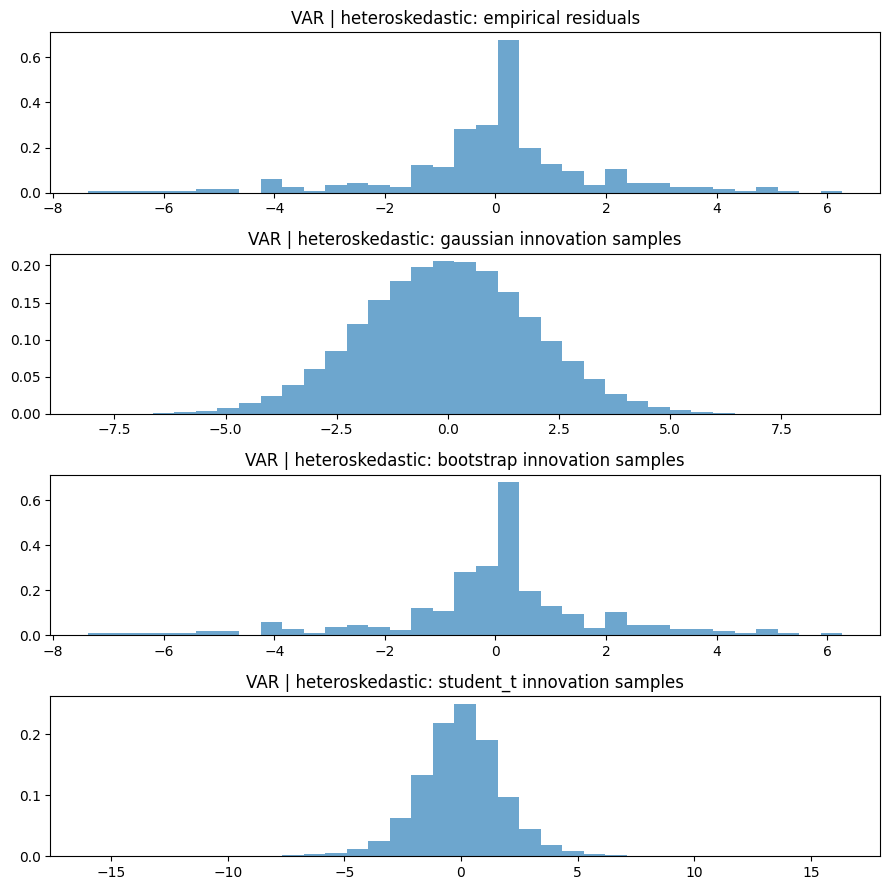

In [5]:
from src.plots.innovations import (
    plot_innovation_comparison,
)

plot_innovation_comparison(
    residual_store=residual_store,
    sampled_innovations=sampled_innovations,
    innovation_model_names=innovation_model_names,
    forecast_model="VAR",
    dgp_name="heteroskedastic",
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "var_heteroskedastic_innovation_comparison.png"
)

print(
    "Saved: var_heteroskedastic_innovation_comparison.png"
)

In [6]:
from src.api.innovations import innovation_recovery_summary

recovery_df = innovation_recovery_summary(
    innovation_diagnostics_df=innovation_diagnostics_df,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    innovation_model_names=innovation_model_names,
)

save_table(
    recovery_df,
    dirs["tables"] / "innovation_recovery_summary.csv",
)

recovery_df

,forecast_model,dgp,innovation_model,kurtosis_error,skewness_error
0,VAR,gaussian,gaussian,0.217453,0.164004
1,VAR,gaussian,bootstrap,0.024552,0.011983
2,VAR,gaussian,student_t,3.954522,0.204216
3,VAR,student_t,gaussian,5.399086,0.628490
4,VAR,student_t,bootstrap,0.046940,0.053158
5,VAR,student_t,student_t,1.361522,0.673194
6,VAR,mixture,gaussian,3.392824,0.149820
7,VAR,mixture,bootstrap,0.060693,0.023949
8,VAR,mixture,student_t,1.698599,0.096664
9,VAR,heteroskedastic,gaussian,2.682489,0.326323


Saved: var_heteroskedastic_innovation_qq_comparison.png


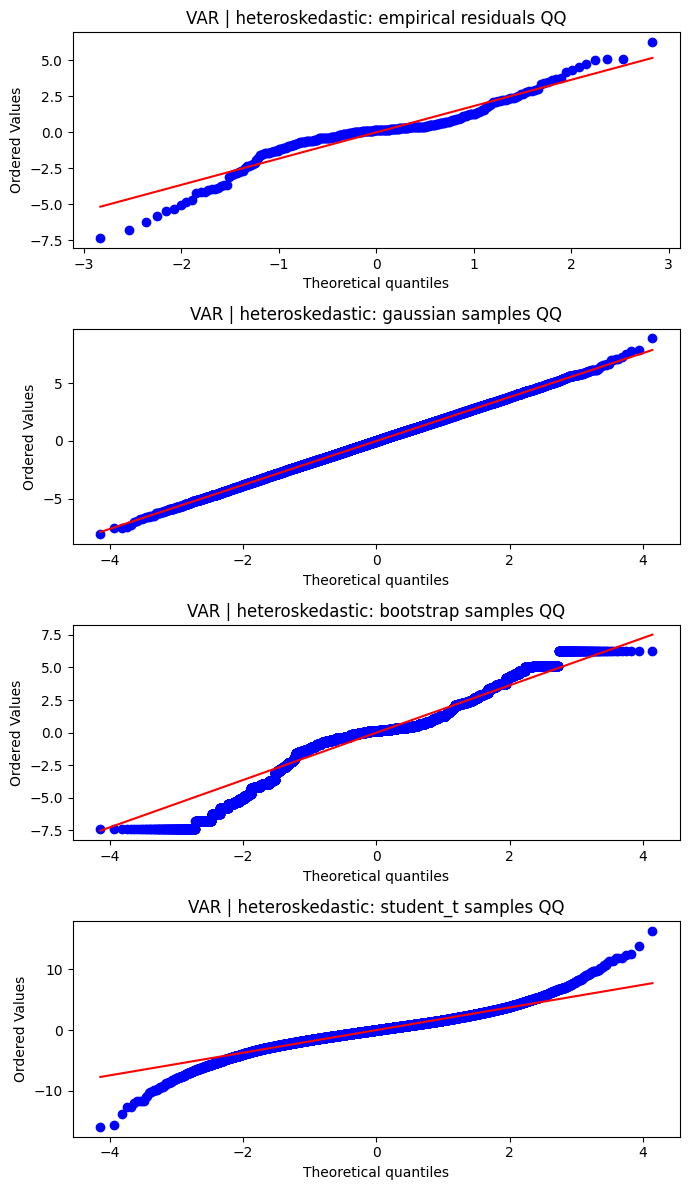

In [7]:
from src.plots.innovations import plot_innovation_qq_comparison

plot_innovation_qq_comparison(
    residual_store=residual_store,
    sampled_innovations=sampled_innovations,
    innovation_model_names=innovation_model_names,
    forecast_model="VAR",
    dgp_name="heteroskedastic",
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "var_heteroskedastic_innovation_qq_comparison.png"
)

print(
    "Saved: var_heteroskedastic_innovation_qq_comparison.png"
)